In [1]:
from __future__ import absolute_import
from __future__ import division
from __future__ import print_function
from __future__ import unicode_literals

import check_util.checker as checker
from IPython.display import clear_output
from PIL import Image

import os
import time
import re
from glob import glob
import shutil
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import tensorflow as tf
from tensorflow.keras import layers

print('tensorflow version: {}'.format(tf.__version__))
print('GPU 사용 가능 여부: {}'.format(tf.test.is_gpu_available()))

tensorflow version: 2.0.0
GPU 사용 가능 여부: False


In [2]:
 import zipfile
 from pathlib import Path

 current_path = Path().absolute()
 data_path = current_path / "data"
 print("현재 디렉토리 위치: {}".format(current_path))
 if (data_path / "my_cat_dog").exists():
     print("이미 'data/my_cat_dog' 폴더에 압축이 풀려있습니다. 확인해보세요!")
 else:
     with zipfile.ZipFile(str(data_path / "my_cat_dog.zip"), "r") as zip_ref:
         zip_ref.extractall(str(data_path / "my_cat_dog"))
     print("Done!")

현재 디렉토리 위치: C:\Users\chang\개,고양이 구분 프로젝트
이미 'data/my_cat_dog' 폴더에 압축이 풀려있습니다. 확인해보세요!


In [3]:
data_dir = './data/my_cat_dog'

In [4]:
checker.dataset_check(data_dir)

훈련용 고양이 이미지 개수: 1000
훈련용 강아지 이미지 개수: 1000
검증용 고양이 이미지 개수: 500
검증용 강아지 이미지 개수: 500
테스트용 고양이 이미지 개수: 1000
테스트용 강아지 이미지 개수: 1000
dataset이 제대로 구성되어 있습니다! 이어서 진행하셔도 좋습니다.


In [5]:
print_steps = 1
val_epoch = 1

batch_size = 20
max_epochs = 20
learning_rate = 1e-4
IMG_SIZE = 150

PATH = data_dir

In [6]:
def load(image_file, label):
    # 해당경로의 파일을 읽어서 float 타입으로 변환합니다.
    image = tf.io.read_file(image_file)
    image = tf.image.decode_jpeg(image)
    image = tf.cast(image, tf.float32)

    return image, label

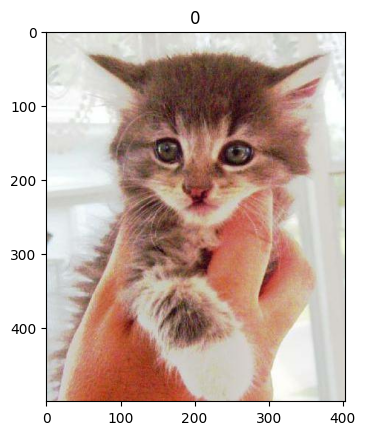

In [7]:
image, label = load(os.path.join(PATH, 'train/cat/cat.100.jpg'), 0)
# casting to int for matplotlib to show the image
plt.figure()
plt.title(label)
plt.imshow(image/255.0)
plt.show()

In [8]:
def resize(input_image, height, width):
    # 원하는 height와 width로 이미지를 resize 합니다.

    ## 코드 시작 ##
    input_image = tf.image.resize(input_image, (height, width))
    ## 코드 종료 ##

    return input_image

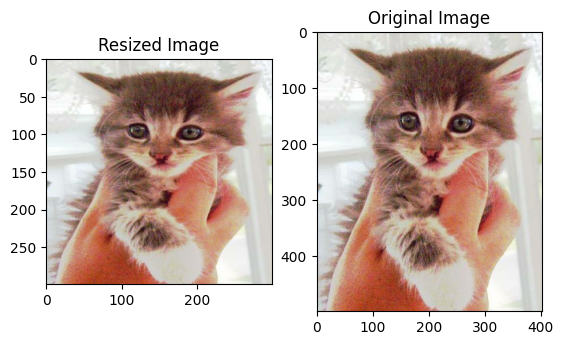

In [9]:
plt.figure()    # 하나의 창
plt.subplot(121)      # 창을 figure에 넣겠다.    plt.subplot(총 행 개수, 총 열 개수, 그래프 번호)
plt.title("Resized Image")   # 제목
plt.imshow(resize(image, 300, 300)/255.0)  # 이미지를 가져와서 보여준다.
plt.subplot(122)      
plt.title("Original Image")
plt.imshow(image/255.0)
plt.show()   # 이미지를 보여준다.

In [10]:
checker.resize_fn_check(resize)

resize 함수를 잘 구현 하셨습니다! 이어서 진행하셔도 좋습니다.


In [11]:
def random_rotation(input_image):
    # 이미지를 원하는 각도(radian)로 회전 시킵니다.

    ## 코드 시작 ##
    angles = np.random.randint(4)    # (0,3)도 가능
    rotated_image = tf.image.rot90(input_image, angles)
    ## 코드 종료 ##  

    return rotated_image

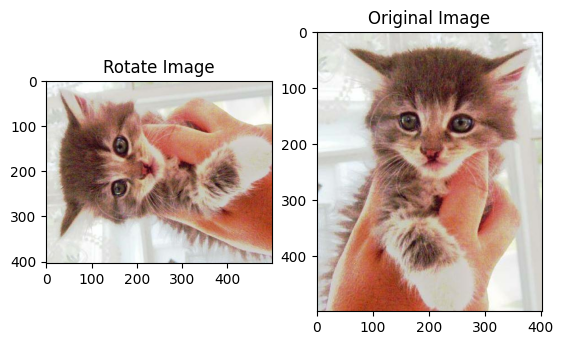

In [12]:
plt.figure()
plt.subplot(121)
plt.title("Rotate Image")
plt.imshow(random_rotation(image)/255.0)
plt.subplot(122)
plt.title("Original Image")
plt.imshow(image/255.0)
plt.show()

In [13]:
def random_crop(input_image):

    ## 코드 시작 ##
    cropped_image = tf.image.random_crop(value=input_image, size=[150, 150, 3])  # 이미지 사이즈를 150으로 설정했으니ㅇ
                                                           #size = [height, width, channel]
    ## 코드 종료 ##

    return cropped_image

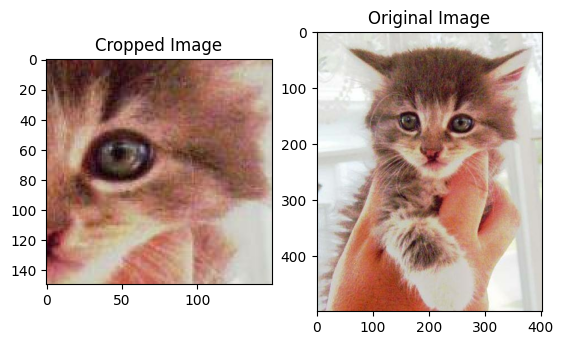

In [14]:
plt.figure()
plt.subplot(121)
plt.title("Cropped Image")
plt.imshow(random_crop(image)/255.0)
plt.subplot(122)
plt.title("Original Image")
plt.imshow(image/255.0)
plt.show()

In [15]:
checker.random_crop_fn_check(random_crop)

random_crop 함수를 잘 구현 하셨습니다! 이어서 진행하셔도 좋습니다.


In [16]:
# normalizing the images to [-1, 1]
def normalize(input_image):
    # 이미지 픽셀값의 범위를 normalize 합니다. [0, 255] -> [-1, 1]

    # 코드 시작
    input_image = (input_image/127.5 - 1)
    # 코드 종료

    return input_image

In [17]:
checker.normalize_fn_check(normalize)

normalize 함수를 잘 구현 하셨습니다! 이어서 진행하셔도 좋습니다.


In [18]:
def random_jitter(input_image):
    # resize, random_crop, random_rotation, random_flip 함수들을 이용하여 augmentation을 합니다.

    ## 코드 시작 ##
    # resizing to 176 x 176 x 3
    input_image = tf.image.resize(input_image, (176, 176))
    # randomly cropping to 150 x 150 x 3
    input_image = tf.image.random_crop(value=input_image, size=[150, 150, 3])
    # randomly rotation
    input_image = random_rotation(input_image)
    # randomly mirroring
    input_image = tf.image.random_flip_left_right(input_image)
    ## 코드 종료 ##

    return input_image

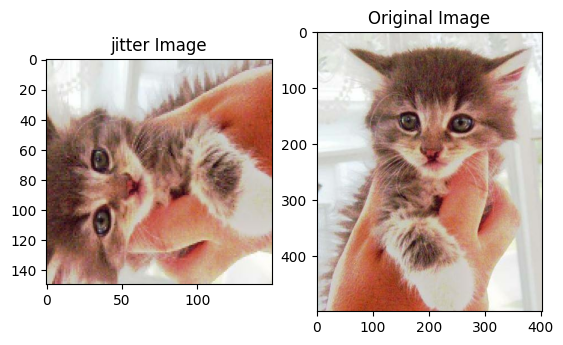

In [19]:
plt.figure()
plt.subplot(121)
plt.title("jitter Image")
plt.imshow(random_jitter(image)/255.0)
plt.subplot(122)
plt.title("Original Image")
plt.imshow(image/255.0)
plt.show()

In [20]:
def central_crop(input_image):
    # 176 x 176 으로 resize후 150 x 150 중앙 crop 합니다.

    ## 코드 시작 ##
    # resizing to 176 x 176 x 3
    input_image = tf.image.resize(input_image, (176, 176))
    # central cropping to 150 x 150 x 3
    input_image = tf.image.central_crop(input_image, central_fraction=(150/176)) #central_fraction = 1이면 원본, 0에 가까울수록 확대.
                                                    #central_fraction의 값은 잘라낸 후(crop한 후) 이미지 크기 / 잘리기 전 이미지 크기
    ## 코드 종료 ##

    return input_image

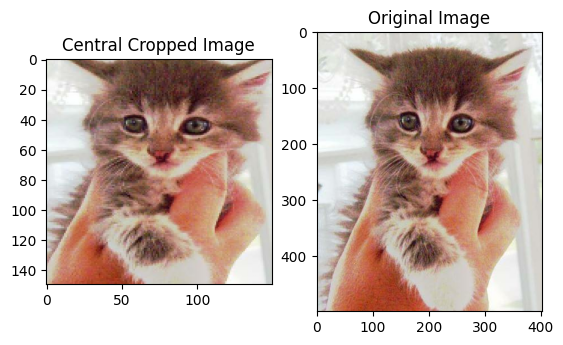

In [21]:
plt.figure()
plt.subplot(121)
plt.title("Central Cropped Image")
plt.imshow(central_crop(image)/255.0)
plt.subplot(122)
plt.title("Original Image")
plt.imshow(image/255.0)
plt.show()

In [22]:
checker.central_crop_fn_check(central_crop)

central_crop 함수를 잘 구현 하셨습니다! 이어서 진행하셔도 좋습니다.


In [23]:
def load_image_train(image_file, label):

    ## 코드 시작 ##
    input_image, label = load(image_file, label)
    input_image = random_jitter(input_image)
    input_image = normalize(input_image)
    ## 코드 종료 ##

    return input_image, label

In [24]:
def load_image_val_and_test(image_file, label):

    ## 코드 시작 ##
    input_image, label = load(image_file, label)
    input_image = central_crop(input_image)
    input_image = normalize(input_image)
    ## 코드 종료 ##

    return input_image, label

In [25]:
def add_label(image_file, label):
    return image_file, label

In [26]:
# train folder에 있는 폴더 이름을 list로 나타냅니다.
# 즉 학습에 사용할 category의 이름을 list로 나타내는 것입니다.
folder_list = [f for f in os.listdir(os.path.join(PATH, 'train')) if not f.startswith('.')]

In [27]:
train_dataset = tf.data.Dataset.list_files(                            # 1번
    os.path.join(PATH, 'train', folder_list[0], '*.jpg'))
train_dataset = train_dataset.map(lambda x: add_label(x, 0))          # 2번
for label, category_name in enumerate(folder_list[1:], 1):            # 3번
    temp_dataset = tf.data.Dataset.list_files(                         # 4번
        os.path.join(PATH, 'train', category_name, '*.jpg'))
    temp_dataset = temp_dataset.map(lambda x: add_label(x, label))    # 5번
    train_dataset = train_dataset.concatenate(temp_dataset)            # 6번

In [28]:
N = BUFFER_SIZE = len(list(train_dataset)) # number of samples in train_dataset
train_dataset = train_dataset.shuffle(BUFFER_SIZE)
train_dataset = train_dataset.map(load_image_train,
                                  num_parallel_calls=16)
train_dataset = train_dataset.batch(batch_size)
train_dataset = train_dataset.repeat()

In [29]:
folder_list = [f for f in os.listdir(os.path.join(PATH, 'val')) if not f.startswith('.')]
val_dataset = tf.data.Dataset.list_files(os.path.join(PATH, 'val', folder_list[0], '*.jpg'))
val_dataset = val_dataset.map(lambda x: add_label(x, 0))
for label, category_name in enumerate(folder_list[1:], 1):
    temp_dataset = tf.data.Dataset.list_files(os.path.join(PATH, 'val', category_name, '*.jpg'))
    temp_dataset = temp_dataset.map(lambda x: add_label(x, label))
    val_dataset = val_dataset.concatenate(temp_dataset)

val_dataset = val_dataset.map(load_image_val_and_test)
val_dataset = val_dataset.batch(batch_size)
val_dataset = val_dataset.repeat()

In [30]:
folder_list = [f for f in os.listdir(os.path.join(PATH, 'test')) if not f.startswith('.')]
test_dataset = tf.data.Dataset.list_files(os.path.join(PATH, 'test', folder_list[0], '*.jpg'))
test_dataset = test_dataset.map(lambda x: add_label(x, 0))
for label, category_name in enumerate(folder_list[1:], 1):
    temp_dataset = tf.data.Dataset.list_files(os.path.join(PATH, 'test', category_name, '*.jpg'))
    temp_dataset = temp_dataset.map(lambda x: add_label(x, label))
    test_dataset = test_dataset.concatenate(temp_dataset)

test_dataset = test_dataset.map(load_image_val_and_test)
test_dataset = test_dataset.shuffle(BUFFER_SIZE)
test_dataset = test_dataset.batch(batch_size)
test_dataset = test_dataset.repeat()

In [31]:
checker.customized_dataset_check(train_dataset)

tf.data.Dataset을 이용하여 train_dataset을 잘 구현하셨습니다! 이어서 진행하셔도 좋습니다.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


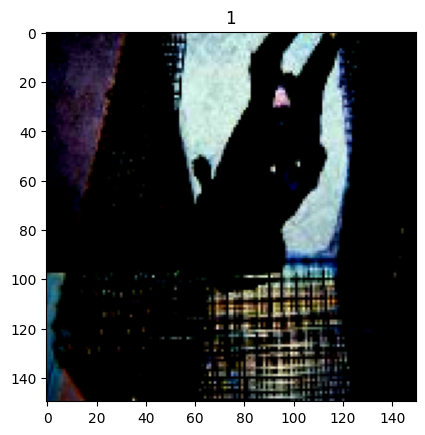

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


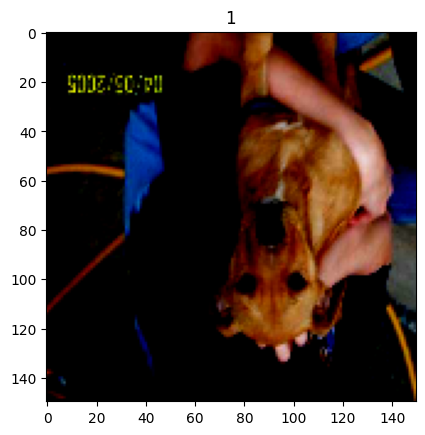

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


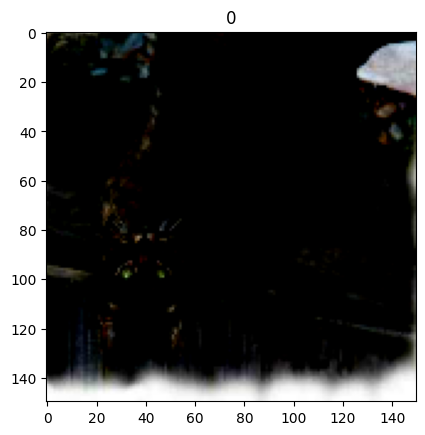

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


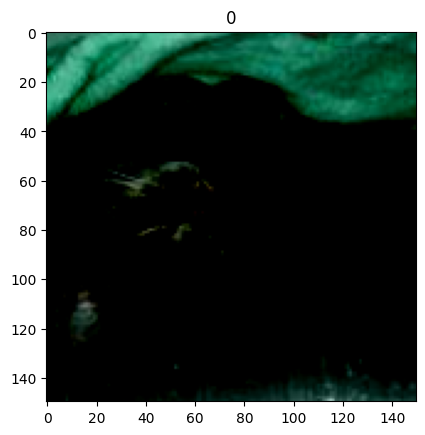

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


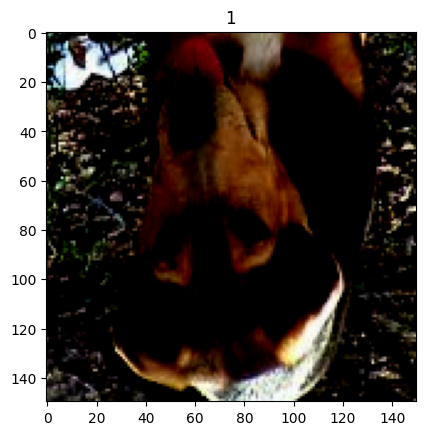

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


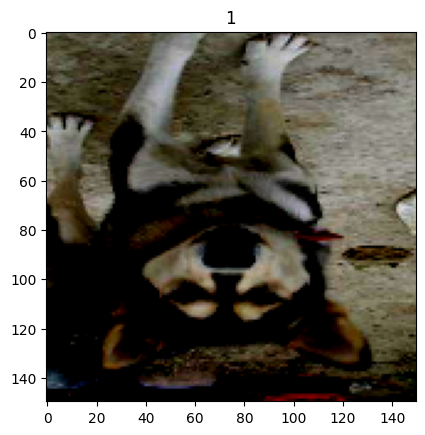

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


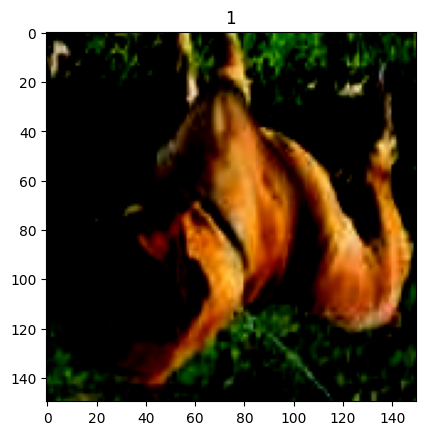

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


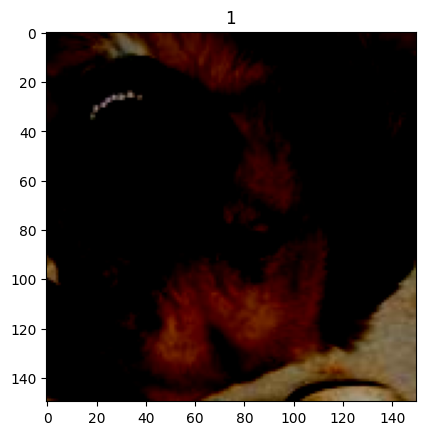

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


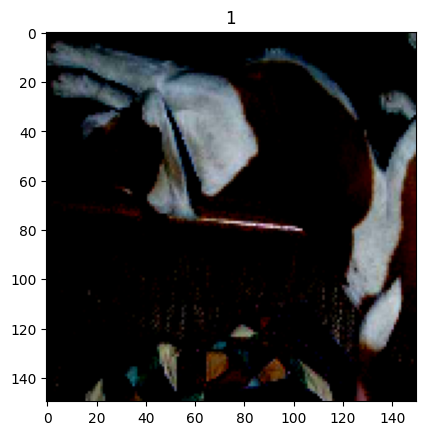

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


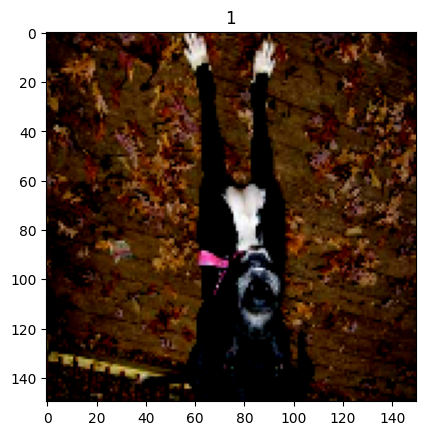

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


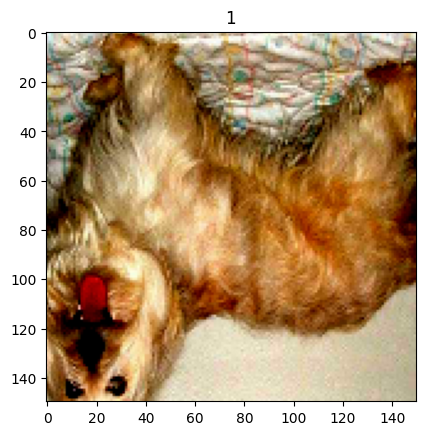

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


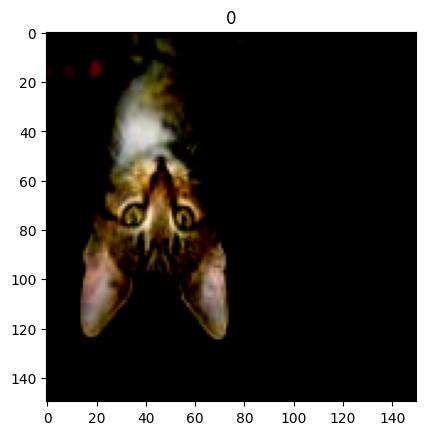

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


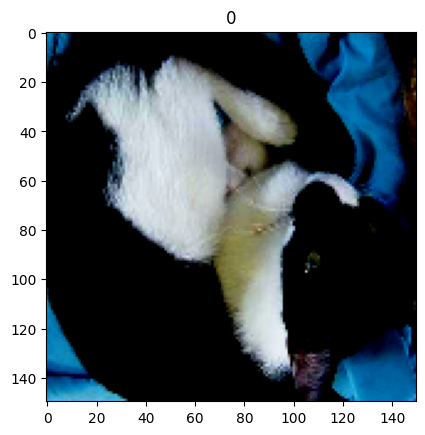

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


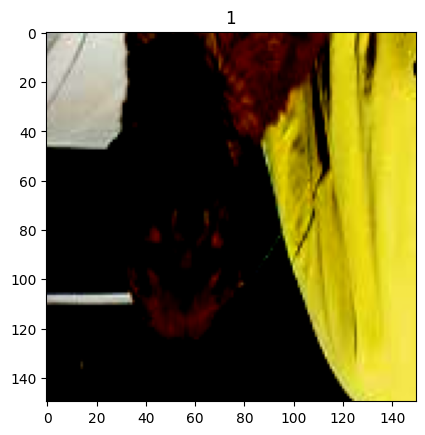

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


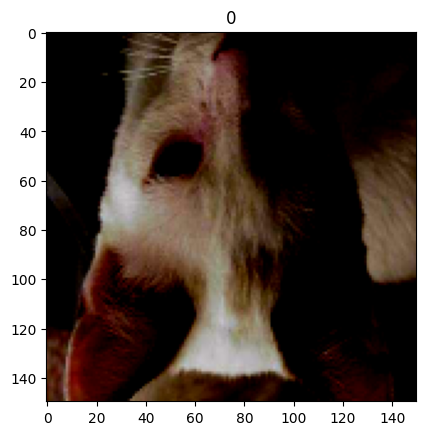

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


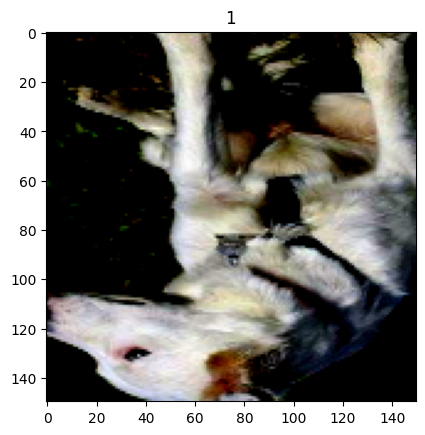

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


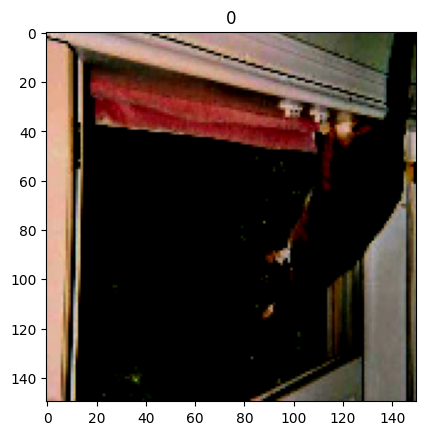

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


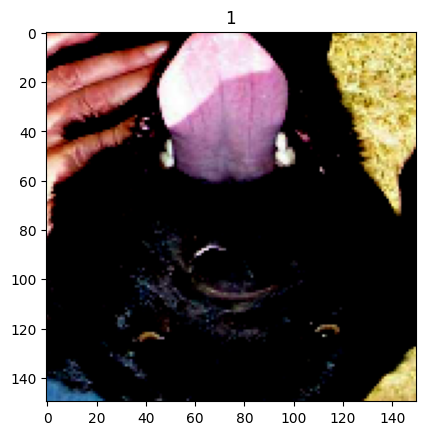

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


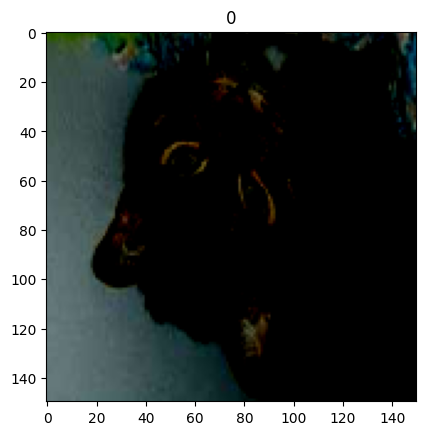

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


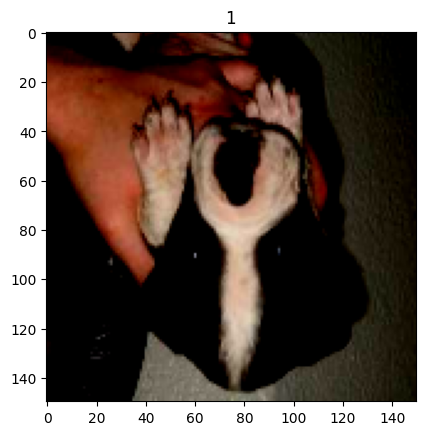

In [32]:
for images, labels in train_dataset.take(1):
    for j in range(20):
        plt.figure()
        plt.imshow(images[j])
        plt.title(labels[j].numpy())
        plt.show()

In [33]:
class Conv(tf.keras.Model):
    def __init__(self, filters, kernel_size):
        super(Conv, self).__init__()

        ## 코드 시작 ##
        self.conv = tf.keras.layers.Conv2D(filters, kernel_size)
        self.bn = tf.keras.layers.BatchNormalization()
        self.relu = tf.keras.layers.ReLU()
        self.pool = tf.keras.layers.MaxPool2D()
        ## 코드 종료 ##

    def call(self, inputs, training=True):

        ## 코드 시작 ##
        
        # 이 파트 궁금
    
        x = self.conv(inputs)    # self.conv forward
        x = self.bn(x)    # self.bn   forward
        x = self.relu(x)    # self.relu forward
        x = self.pool(x)    # self.pool forward
        ## 코드 종료 ##

        return x

In [34]:
model = tf.keras.Sequential()

##코드 시작##
model.add(Conv(32, 3))        # model.add(Conv(filters, kernel_size)),  즉 Conv(출력 채널 수, 필터 크기)
model.add(Conv(64, 3))
model.add(Conv(128, 3))
model.add(Conv(128, 3))

model.add(tf.keras.layers.Flatten())  # flatten
model.add(tf.keras.layers.Dense(512, activation='relu'))  # relu
model.add(tf.keras.layers.Dense(2, activation='softmax'))  # softmax
##코드 종료##

In [35]:
model(images[:1])

<tf.Tensor: id=5337, shape=(1, 2), dtype=float32, numpy=array([[0.5381902 , 0.46180984]], dtype=float32)>

In [36]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv (Conv)                  multiple                  1024      
_________________________________________________________________
conv_1 (Conv)                multiple                  18752     
_________________________________________________________________
conv_2 (Conv)                multiple                  74368     
_________________________________________________________________
conv_3 (Conv)                multiple                  148096    
_________________________________________________________________
flatten (Flatten)            multiple                  0         
_________________________________________________________________
dense (Dense)                multiple                  3211776   
_________________________________________________________________
dense_1 (Dense)              multiple                  1

In [37]:
checker.model_check(model)

네트워크를 잘 구현하셨습니다! 이어서 진행하셔도 좋습니다.


In [38]:
checkpoint_path = "./train/exp_cnn/cp-{epoch:04d}.ckpt"
checkpoint_dir = os.path.dirname(checkpoint_path)

## 코드 시작 ##
# 체크포인트 콜백 만들기
cp_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path, save_weights_only=True, verbose=1)
# tf.keras.callbacks.ModelCheckpoint(파일 경로, 모델 weights 저장(True면 weight만 저장, False면 모델 레이어 및 weight 모두 저장))
# verbose = 1 이면 모델이 저장 될 때 저장되었습니다 표시, 0이면 아무것도 없이 바로 저장
## 코드 종료 ##

In [39]:
checker.callback_check(cp_callback)

callback을 잘 정의하셨습니다! 이어서 진행하셔도 좋습니다.


In [40]:
## 코드 시작 ##
model.compile(optimizer = tf.keras.optimizers.Adam(learning_rate), 
              loss = 'sparse_categorical_crossentropy', 
              metrics = ['accuracy'])
## 코드 종료 ##

In [41]:
checker.compile_check(model)

compile을 잘 정의하셨습니다! 이어서 진행하셔도 좋습니다.


In [42]:
train_len = len(glob(os.path.join(PATH, 'train', folder_list[0], '*.jpg'))) * 2
val_len = len(glob(os.path.join(PATH, 'val', folder_list[0], '*.jpg'))) * 2
test_len = len(glob(os.path.join(PATH, 'test', folder_list[0], '*.jpg'))) * 2

In [43]:
## 코드 시작 ##
model.fit(train_dataset, steps_per_epoch = train_len / batch_size,
          validation_data = val_dataset,     # validation_data 궁금
          validation_steps = val_len / batch_size,   # validation_steps 궁금
          epochs = max_epochs,          # 파라미터에 지정한 변수 이용
          callbacks = [cp_callback])
## 코드 종료 ##

Train for 100.0 steps, validate for 50.0 steps
Epoch 1/20
 99/100 [============================>.] - ETA: 0s - loss: 1.4768 - accuracy: 0.5732
Epoch 00001: saving model to ./train/exp_cnn/cp-0001.ckpt
100/100 [==============================] - 60s 601ms/step - loss: 1.4687 - accuracy: 0.5740 - val_loss: 0.7109 - val_accuracy: 0.5000
Epoch 2/20
 99/100 [============================>.] - ETA: 0s - loss: 0.6481 - accuracy: 0.6510
Epoch 00002: saving model to ./train/exp_cnn/cp-0002.ckpt
100/100 [==============================] - 60s 603ms/step - loss: 0.6478 - accuracy: 0.6515 - val_loss: 0.7413 - val_accuracy: 0.5020
Epoch 3/20
 99/100 [============================>.] - ETA: 0s - loss: 0.5861 - accuracy: 0.6848
Epoch 00003: saving model to ./train/exp_cnn/cp-0003.ckpt
100/100 [==============================] - 59s 593ms/step - loss: 0.5845 - accuracy: 0.6860 - val_loss: 0.8107 - val_accuracy: 0.5080
Epoch 4/20
 99/100 [============================>.] - ETA: 0s - loss: 0.5562 - accuracy: 

In [1]:
checker.accuracy_check(model)

NameError: name 'checker' is not defined

In [46]:
model = tf.keras.Sequential()

##코드 시작##
model.add(Conv(32, 3))
model.add(Conv(64, 3))
model.add(Conv(128, 3))
model.add(Conv(128, 3))

model.add(tf.keras.layers.Flatten())  # flatten
model.add(tf.keras.layers.Dense(512, activation='relu'))  # relu
model.add(tf.keras.layers.Dense(2, activation='softmax'))  # softmax

model.compile(optimizer = 'adam', 
              loss = 'sparse_categorical_crossentropy', 
              metrics = ['accuracy'])
##코드 종료##

# inputs을 넣어 모델 생성
for images, labels in train_dataset.take(1):
    outputs = model(images, training=False)

In [47]:
latest = tf.train.latest_checkpoint(checkpoint_dir)
latest

'./train/exp_cnn\\cp-0020.ckpt'

In [48]:
model.load_weights(latest)

In [49]:
model.evaluate(test_dataset, steps=test_len/batch_size)

100/100 [==============================] - 11s 110ms/step - loss: 0.7641 - accuracy: 0.6450


[0.7640576900541782, 0.645]

In [50]:
checker.test_check(model)

Test Accuracy가 낮습니다. Model의 구조와 Data Input, Output을 확인해주세요.


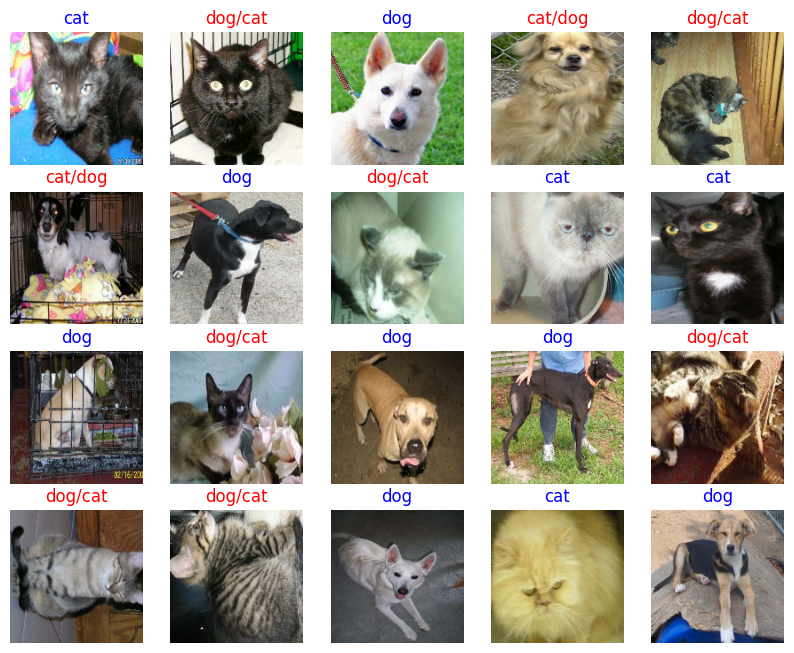

In [51]:
test_batch_size = 25

for images, labels in test_dataset.take(1):
    predictions = model(images)

images = images[:test_batch_size]
labels = labels[:test_batch_size]
predictions = predictions[:test_batch_size]

labels_map = {0: 'cat', 1: 'dog'}

# 시각화
fig = plt.figure(figsize=(10, 10))
for i, (px, py, y_pred) in enumerate(zip(images, labels, predictions)):
    p = fig.add_subplot(5, 5, i+1)
    if np.argmax(y_pred.numpy()) == py.numpy():
        p.set_title("{}".format(labels_map[py.numpy()]), color='blue')
    else:
        p.set_title("{}/{}".format(labels_map[np.argmax(y_pred.numpy())],
                                   labels_map[py.numpy()]), color='red')
    p.imshow(px.numpy()*0.5+0.5)
    p.axis('off')

In [52]:
conv_base = tf.keras.applications.VGG16(weights='imagenet',
                                        include_top=False,
                                        input_shape=(IMG_SIZE, IMG_SIZE, 3))

In [53]:
model = tf.keras.Sequential()
model.add(conv_base)
model.add(layers.Flatten())

# 코드 시작
model.add(tf.keras.layers.Dense(256, activation='relu'))
model.add(tf.keras.layers.Dense(256, activation='softmax'))
# 코드 종료

In [54]:
# training variable 확인
for var in model.trainable_variables:
    print(var.name)

block1_conv1/kernel:0
block1_conv1/bias:0
block1_conv2/kernel:0
block1_conv2/bias:0
block2_conv1/kernel:0
block2_conv1/bias:0
block2_conv2/kernel:0
block2_conv2/bias:0
block3_conv1/kernel:0
block3_conv1/bias:0
block3_conv2/kernel:0
block3_conv2/bias:0
block3_conv3/kernel:0
block3_conv3/bias:0
block4_conv1/kernel:0
block4_conv1/bias:0
block4_conv2/kernel:0
block4_conv2/bias:0
block4_conv3/kernel:0
block4_conv3/bias:0
block5_conv1/kernel:0
block5_conv1/bias:0
block5_conv2/kernel:0
block5_conv2/bias:0
block5_conv3/kernel:0
block5_conv3/bias:0
dense_4/kernel:0
dense_4/bias:0
dense_5/kernel:0
dense_5/bias:0


In [55]:
conv_base.trainable = True
set_trainable = False
for layer in conv_base.layers:
    if layer.name == 'block5_conv1':
        set_trainable = True
    if set_trainable:
        layer.trainable = True
    else:
        layer.trainable = False

In [56]:
# training variable 확인
for var in model.trainable_variables:
    print(var.name)

block5_conv1/kernel:0
block5_conv1/bias:0
block5_conv2/kernel:0
block5_conv2/bias:0
block5_conv3/kernel:0
block5_conv3/bias:0
dense_4/kernel:0
dense_4/bias:0
dense_5/kernel:0
dense_5/bias:0


In [57]:
checker.final_dense_check(model)

마지막 dense layer의 출력 feature 수가 잘못되었습니다. 지문을 다시 확인하시기 바랍니다.


In [58]:
## 코드 시작 ##
model.compile(optimizer = 'adam', 
              loss = 'sparse_categorical_crossentropy', 
              metrics = ['accuracy'])
## 코드 종료 ##

In [59]:
checkpoint_path = "./train/exp_pre_trained/cp.ckpt"
checkpoint_dir = os.path.dirname(checkpoint_path)

# 체크포인트 콜백 만들기
## 코드 시작 ##
cp_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path, save_weights_only=True, verbose=1)
## 코드 종료 ##

In [60]:
model.fit(train_dataset, steps_per_epoch = train_len / batch_size,
          validation_data= val_dataset, 
          validation_steps= val_len / batch_size,
          epochs= 5,
          callbacks= [cp_callback])

Train for 100.0 steps, validate for 50.0 steps
Epoch 1/5
 99/100 [============================>.] - ETA: 1s - loss: 0.9184 - accuracy: 0.5828
Epoch 00001: saving model to ./train/exp_pre_trained/cp.ckpt
100/100 [==============================] - 138s 1s/step - loss: 0.9115 - accuracy: 0.5865 - val_loss: 0.7446 - val_accuracy: 0.7080
Epoch 2/5
 99/100 [============================>.] - ETA: 1s - loss: 0.3522 - accuracy: 0.8545
Epoch 00002: saving model to ./train/exp_pre_trained/cp.ckpt
100/100 [==============================] - 138s 1s/step - loss: 0.3518 - accuracy: 0.8545 - val_loss: 0.7585 - val_accuracy: 0.6470
Epoch 3/5
 99/100 [============================>.] - ETA: 0s - loss: 0.2505 - accuracy: 0.9056
Epoch 00003: saving model to ./train/exp_pre_trained/cp.ckpt
100/100 [==============================] - 134s 1s/step - loss: 0.2504 - accuracy: 0.9050 - val_loss: 0.6981 - val_accuracy: 0.6690
Epoch 4/5
 99/100 [============================>.] - ETA: 0s - loss: 0.1910 - accuracy: 0

In [61]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
vgg16 (Model)                (None, 4, 4, 512)         14714688  
_________________________________________________________________
flatten_2 (Flatten)          (None, 8192)              0         
_________________________________________________________________
dense_4 (Dense)              (None, 256)               2097408   
_________________________________________________________________
dense_5 (Dense)              (None, 256)               65792     
Total params: 16,877,888
Trainable params: 9,242,624
Non-trainable params: 7,635,264
_________________________________________________________________


In [62]:
model.load_weights(tf.train.latest_checkpoint(checkpoint_dir))

In [63]:
model.evaluate(test_dataset, steps= test_len/batch_size)

100/100 [==============================] - 72s 724ms/step - loss: 1.1222 - accuracy: 0.6465


[1.122233049571514, 0.6465]